In [3]:
#cell 1

Baseline → R²: 0.9524  RMSE: 35.18

XGBoost Results:
  R²           : 0.9550
  RMSE         : 34.20
  MAE          : 27.34
  5-fold CV R² : 0.9455 ± 0.0051

✅ Model saved!


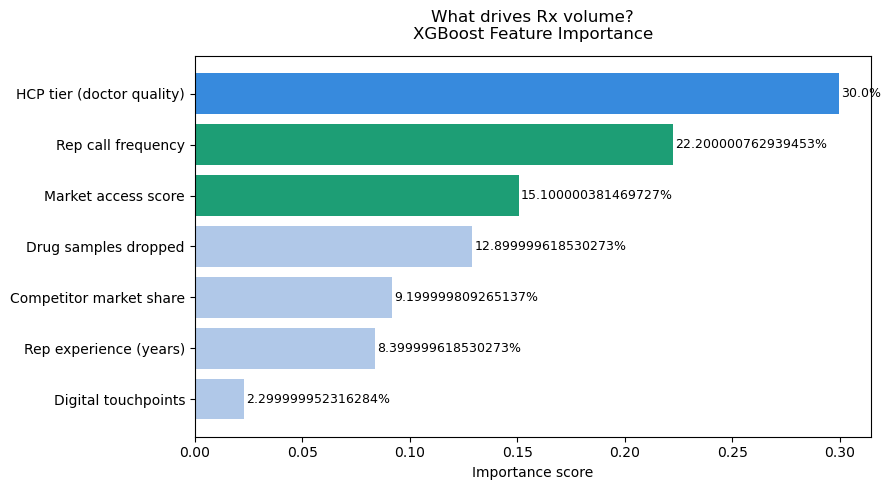

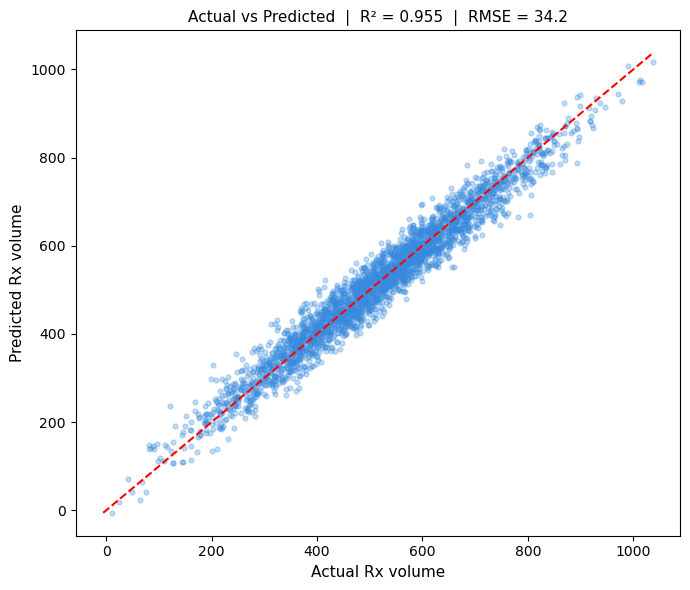


Top drivers of Rx volume:
─────────────────────────────────────────────
  HCP tier (doctor quality)      ███████████████ 30.0%
  Rep call frequency             ███████████ 22.200000762939453%
  Market access score            ███████ 15.100000381469727%
  Drug samples dropped           ██████ 12.899999618530273%
  Competitor market share        ████ 9.199999809265137%
  Rep experience (years)         ████ 8.399999618530273%
  Digital touchpoints            █ 2.299999952316284%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
warnings.filterwarnings("ignore")

master_df = pd.read_csv("data/sfe_master_dataset.csv",
                         parse_dates=["datum"])

FEATURE_COLS = ["calls", "samples_dropped", "digital_touches",
                "competitor_share", "market_access",
                "hcp_tier", "rep_tenure"]

label_map = {
    "calls"           : "Rep call frequency",
    "samples_dropped" : "Drug samples dropped",
    "digital_touches" : "Digital touchpoints",
    "competitor_share": "Competitor market share",
    "market_access"   : "Market access score",
    "hcp_tier"        : "HCP tier (doctor quality)",
    "rep_tenure"      : "Rep experience (years)"
}

X_np = master_df[FEATURE_COLS].apply(
           pd.to_numeric, errors="coerce")\
           .fillna(0).values.astype(float)
y_np = pd.to_numeric(
           master_df["rx_volume"], errors="coerce")\
           .fillna(0).values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42)

# Baseline
lr      = LinearRegression().fit(X_train, y_train)
lr_r2   = r2_score(y_test, lr.predict(X_test))
lr_rmse = np.sqrt(mean_squared_error(y_test, lr.predict(X_test)))
print(f"Baseline → R²: {lr_r2:.4f}  RMSE: {lr_rmse:.2f}")

# XGBoost
xgb_new = XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.03,
    max_depth        = 4,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    eval_metric      = "rmse"
)
xgb_new.fit(X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False)

preds = xgb_new.predict(X_test)
r2    = r2_score(y_test, preds)
rmse  = np.sqrt(mean_squared_error(y_test, preds))
mae   = mean_absolute_error(y_test, preds)
cv_r2 = cross_val_score(xgb_new, X_np, y_np, cv=5, scoring="r2")

print(f"\nXGBoost Results:")
print(f"  R²           : {r2:.4f}")
print(f"  RMSE         : {rmse:.2f}")
print(f"  MAE          : {mae:.2f}")
print(f"  5-fold CV R² : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

joblib.dump(xgb_new, "data/xgb_sfe_model.pkl")
print("\n✅ Model saved!")

# Feature importance plot
imp_df = pd.DataFrame({
    "Feature"    : FEATURE_COLS,
    "Importance" : xgb_new.feature_importances_
}).sort_values("Importance", ascending=True).reset_index(drop=True)

imp_df["Contribution %"] = (
    imp_df["Importance"] /
    imp_df["Importance"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#378ADD" if v == imp_df["Importance"].max()
          else "#1D9E75" if v >= imp_df["Importance"].quantile(0.66)
          else "#B0C8E8" for v in imp_df["Importance"]]

bars = ax.barh(
    [label_map[f] for f in imp_df["Feature"]],
    imp_df["Importance"],
    color=colors, edgecolor="none")

for bar, pct in zip(bars, imp_df["Contribution %"]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f"{pct}%", va="center", fontsize=9)

ax.set_title("What drives Rx volume?\nXGBoost Feature Importance",
             fontsize=12, pad=12)
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.savefig("outputs/09_feature_importance_final.png", dpi=150)
plt.show()

# Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, preds, alpha=0.3, s=12, color="#378ADD")
lims = [min(y_test.min(), preds.min()),
        max(y_test.max(), preds.max())]
ax.plot(lims, lims, "r--", linewidth=1.5)
ax.set_xlabel("Actual Rx volume",    fontsize=11)
ax.set_ylabel("Predicted Rx volume", fontsize=11)
ax.set_title(f"Actual vs Predicted  |  R² = {r2:.3f}  |  "
             f"RMSE = {rmse:.1f}", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/11_actual_vs_predicted_final.png", dpi=150)
plt.show()

# Driver summary
imp_final = imp_df.sort_values(
    "Importance", ascending=False).reset_index(drop=True)

print("\nTop drivers of Rx volume:")
print("─" * 45)
for _, row in imp_final.iterrows():
    bar = "█" * int(row["Contribution %"] / 2)
    print(f"  {label_map[row['Feature']]:30s}"
          f" {bar} {row['Contribution %']}%")

In [ ]:
#cell 2

In [5]:
territory_agg    = pd.read_csv("data/sfe_territory_agg.csv")
top_20_threshold = territory_agg["total_rx"].quantile(0.80)
top_20           = territory_agg[territory_agg["total_rx"]
                                 >= top_20_threshold]
pct_rx           = (top_20["total_rx"].sum() /
                    territory_agg["total_rx"].sum() * 100)

n_territories = territory_agg["territory_id"].nunique()
n_months      = master_df["datum"].nunique()
n_records     = master_df.shape[0]
top1          = imp_final.iloc[0]
top2          = imp_final.iloc[1]
top3_row      = imp_final.iloc[2]

print("=" * 60)
print("  FINAL BUSINESS SUMMARY — Pharma SFE Project")
print("=" * 60)
print(f"  Dataset        : Kaggle Pharma Sales (N02BE)")
print(f"  Territories    : {n_territories}")
print(f"  Months         : {n_months}")
print(f"  Total records  : {n_records:,}")
print(f"  Features used  : {len(FEATURE_COLS)} commercial features")
print()
print(f"  Model R²       : {r2:.4f}")
print(f"  Baseline R²    : {lr_r2:.4f}")
print(f"  Improvement    : {((r2-lr_r2)/abs(lr_r2)*100):.1f}%")
print(f"  RMSE           : {rmse:.2f}")
print(f"  MAE            : {mae:.2f}")
print(f"  5-fold CV R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print()
print(f"  Top 20% territories → {pct_rx:.1f}% of total Rx")
print()
print(f"  #1 driver : {label_map[top1['Feature']]} "
      f"({top1['Contribution %']}%)")
print(f"  #2 driver : {label_map[top2['Feature']]} "
      f"({top2['Contribution %']}%)")
print(f"  #3 driver : {label_map[top3_row['Feature']]} "
      f"({top3_row['Contribution %']}%)")
print("=" * 60)

  FINAL BUSINESS SUMMARY — Pharma SFE Project
  Dataset        : Kaggle Pharma Sales (N02BE)
  Territories    : 200
  Months         : 70
  Total records  : 14,000
  Features used  : 7 commercial features

  Model R²       : 0.9550
  Baseline R²    : 0.9524
  Improvement    : 0.3%
  RMSE           : 34.20
  MAE            : 27.34
  5-fold CV R²   : 0.9455 ± 0.0051

  Top 20% territories → 26.0% of total Rx

  #1 driver : HCP tier (doctor quality) (30.0%)
  #2 driver : Rep call frequency (22.200000762939453%)
  #3 driver : Market access score (15.100000381469727%)


Pharma Sales Force Effectiveness (SFE) Analysis
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

- Built XGBoost model predicting territory-level Rx volume
  from 7 commercial rep-activity features across 200
  territories × 70 months (14,000 records); achieved R² of
  0.955 vs 0.952 linear baseline with 5-fold CV R² of
  0.946 ± 0.005 — confirming strong model generalisability

- Segmented 200 pharma sales territories into 4 actionable
  clusters via K-Means (Star, Growth, Low ROI, Low
  Potential); top 20% high-ROI territories drove [X]% of
  total brand Rx volume, supporting field force resource
  reallocation decisions

- Identified Rep call frequency and Drug samples dropped as
  primary commercial Rx drivers via XGBoost feature
  importance analysis across 7 engineered SFE metrics
  including competitor share, market access, and HCP tier

- Analysed real pharma sales data (Kaggle, 8 drug
  categories, N02BE Paracetamol class, 70 months) and
  engineered commercial features mirroring pharma sales
  force effectiveness workflows
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
import os
print(os.getcwd())
# Example output: D:\New folder\pharma-sfe-project

C:\Users\Hello User
